# 📦 第 60 课 · 用 Triton 写 mini 算子库

> LayerNorm / GELU / Softmax 的 triton 实现、封装与性能对比,以及 Triton 生态全景

**章节**: 第 9 章 · Triton 编程

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 用 triton 实现 LayerNorm / GELU / Softmax 三个经典算子
- 把 kernel 封装成可复用的 Python API(像 vLLM 的 ops 目录那样)
- 与 torch 原生算子做性能对比,理解 triton 的适用场景与边界
- 认识 Triton 生态:triton-lang / triton-mosaic / OpenAI 与 CUDA/CUTLASS 的关系

## 📑 本课目录

1. **直觉:算子库是“积木箱”** — 写一次 kernel,封装成函数,处处调用
2. **LayerNorm:一行一次统计** — mean / var / rstd 一次扫完,乘 γ 加 β
3. **GELU:精确 vs 近似** — erf 版精确,tanh 版更快,逐元素无数据依赖
4. **Softmax:减 max 的威力** — 数值稳定一行搞定,数据沿行内复用
5. **封装:一个 mini 算子库的 API 设计** — 注册表 + 统一签名 + 后端可替换
6. **性能对比:bar chart 见真章** — 访存受限算子上,triton vs torch 各说各话
7. **融合的艺术:layer_norm + gelu** — 一个 kernel 一次读写,vs 两个 kernel 两次读写
8. **Triton 生态全景** — triton-lang / triton-mosaic / OpenAI 生态与 CUTLASS 的关系
9. **配套 Streamlit 演示** — app_60_triton_oplib.py:算子选择器对比

## 🔗 参考资料

- [Triton 官方教程:矩阵乘(进阶)](https://triton-lang.org/main/getting-started/tutorials/03-matrix-multiplication.html)
- [triton-mosaic(Intel 维护的 Triton fork)](https://github.com/intel/triton-mosaic)
- [OpenAI Triton 介绍博客](https://openai.com/research/triton)
- [CUTLASS(NVIDIA 手写 CUDA 模板库)](https://github.com/NVIDIA/cutlass)

## 1️⃣ 直觉:算子库是“积木箱” 🧰

把注意力 kernel、GEMM、归一化算子看成**积木**:写一次、封装好、到处复用——这就是**算子库
(oplib)**。vLLM 自己也有一个 ops 目录(`vllm/v1/attention/ops/`),里面全是 triton 写的
小 kernel(`triton_prefill_attention.py`、`triton_reshape_and_cache_flash.py`……),
按需拼装成完整的注意力后端。

本课我们用 Triton 实现三个“积木”:**LayerNorm、GELU、Softmax**,把它们封装成统一接口,
与 torch 原生实现做性能对比,最后聊聊 Triton 生态。你会发现一个反直觉的结论:
**对简单的访存受限算子,triton 未必比 torch 快**——triton 的真正价值在于“融合”和“定制”。

✅ 环境自检:本课三个算子都要真实编译运行。

In [1]:
# -*- coding: utf-8 -*-
# 环境自检:KMP 防护 + 指定可用 ptxas + 打印 GPU/triton 信息
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")          # Windows OMP 冲突防护
_PTXAS = r"D:\CUDA\v13.3\bin\ptxas.exe"                     # 系统 CUDA 自带 ptxas
if os.path.exists(_PTXAS):                                      # 内嵌 ptxas 在本机编译失败
    os.environ["TRITON_PTXAS_PATH"] = _PTXAS
import math, time
import numpy as np
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font=["Microsoft YaHei", "DejaVu Sans"])
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200

torch.manual_seed(0)
print("torch   :", torch.__version__)
print("triton  :", triton.__version__)
print("CUDA    :", torch.cuda.is_available())
print("GPU     :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
print("ptxas   :", os.environ.get("TRITON_PTXAS_PATH", "内嵌"))

torch   : 2.11.0+cu128
triton  : 3.7.1
CUDA    : True
GPU     : NVIDIA GeForce RTX 5060 Laptop GPU
ptxas   : D:\CUDA\v13.3\bin\ptxas.exe


## 2️⃣ LayerNorm:一行一次统计 📐

LayerNorm 对每一行做归一化:

$$y_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}\cdot\gamma_i + \beta_i,
\quad \mu=\frac{1}{N}\sum_j x_j,\ \sigma^2=\frac{1}{N}\sum_j(x_j-\mu)^2$$

它天然适合“一行一个 program”:整行读进来,块内两次归约(mean、var),最后乘 γ 加 β。
注意 mask 行的处理:读入时把无效列置 0,`tl.where` 后再参与统计,避免污染 mean/var。

📐 三个 kernel 一并给出:LayerNorm / GELU / Softmax。每个都是“小、独立、可复用”的积木。

In [2]:
# ---- ① LayerNorm ----
@triton.jit
def layer_norm_fwd(x_ptr, y_ptr, w_ptr, b_ptr, eps, M, N, row_stride,
                   BLOCK_N: tl.constexpr):
    """LayerNorm:每行一个 program。mean/var 在块内一次算完,最后乘 γ 加 β。"""
    row = tl.program_id(0)
    offs = tl.arange(0, BLOCK_N)
    mask = offs < N
    x = tl.load(x_ptr + row * row_stride + offs, mask=mask, other=0.0)
    mean = tl.sum(x, axis=0) / N
    xc = tl.where(mask, x - mean, 0.0)
    var = tl.sum(xc * xc, axis=0) / N
    rstd = 1.0 / tl.sqrt(var + eps)
    w = tl.load(w_ptr + offs, mask=mask, other=0.0)
    b = tl.load(b_ptr + offs, mask=mask, other=0.0)
    tl.store(y_ptr + row * row_stride + offs, (xc * rstd) * w + b, mask=mask)


def layer_norm_triton(x, w, b, eps=1e-5):
    M, N = x.shape
    y = torch.empty_like(x)
    layer_norm_fwd[(M,)](x, y, w, b, eps, M, N, N, BLOCK_N=triton.next_power_of_2(N))
    return y


# ---- ② GELU(精确 erf 版)----
@triton.jit
def gelu_fwd(x_ptr, o_ptr, N, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    offs = pid * BLOCK + tl.arange(0, BLOCK)
    mask = offs < N
    x = tl.load(x_ptr + offs, mask=mask)
    o = 0.5 * x * (1.0 + tl.math.erf(x * 0.7071067811865476))   # x/√2
    tl.store(o_ptr + offs, o, mask=mask)


def gelu_triton(x, BLOCK=1024):
    n = x.numel()
    o = torch.empty_like(x)
    gelu_fwd[(triton.cdiv(n, BLOCK),)](x, o, n, BLOCK=BLOCK)
    return o


# ---- ③ Softmax(数值稳定:减 max)----
@triton.jit
def softmax_fwd(x_ptr, o_ptr, M, N, row_stride, BLOCK_N: tl.constexpr):
    row = tl.program_id(0)
    offs = tl.arange(0, BLOCK_N)
    mask = offs < N
    x = tl.load(x_ptr + row * row_stride + offs, mask=mask, other=float("-inf"))
    m = tl.max(x, axis=0)                        # 先减 max,防 exp 溢出
    p = tl.exp(x - m)
    s = tl.sum(p, axis=0)
    tl.store(o_ptr + row * row_stride + offs, p / s, mask=mask)


def softmax_triton(x, BLOCK_N=128):
    M, N = x.shape
    o = torch.empty_like(x)
    softmax_fwd[(M,)](x, o, M, N, N, BLOCK_N=triton.next_power_of_2(N))
    return o

✅ 与 torch 的 LayerNorm 对拍,误差应 < 1e-5(fp32)。

In [3]:
M, N = 512, 256
x = torch.randn(M, N, device="cuda")
w = torch.randn(N, device="cuda")
b = torch.randn(N, device="cuda")

y_tri = layer_norm_triton(x, w, b)
y_ref = torch.nn.functional.layer_norm(x, (N,), w, b, 1e-5)
print("LayerNorm max err =", (y_tri - y_ref).abs().max().item())

LayerNorm max err = 1.9073486328125e-06


## 3️⃣ GELU:精确 vs 近似 📈

GELU(Gaussian Error Linear Unit)是 Transformer 里常用的激活:

$$\text{GELU}(x) = 0.5x\Big(1 + \text{erf}\big(x/\sqrt{2}\big)\Big)$$

- **精确版**用 `tl.math.erf`(我们实现的就是它),一步到位;
- **近似版**(`0.5x(1+tanh(√(2/π)(x+0.044715x³)))`)不用 erf,某些平台上更快。

GELU 是逐元素算子,**没有任何跨元素依赖**,是 triton 最容易写的一类——但也意味着
它几乎纯访存受限。对拍一下:

✅ 误差 ~1e-7(fp32 内 erf 实现略有差异)。

In [4]:
x = torch.randn(M * N, device="cuda")
y_tri = gelu_triton(x)
y_ref = torch.nn.functional.gelu(x)
print("GELU max err =", (y_tri - y_ref).abs().max().item())

GELU max err = 4.76837158203125e-07


## 4️⃣ Softmax:减 max 的威力 🌊

Softmax 每行是“跨元素”运算:先减 max 保证 `exp` 不溢出,再求和归一。triton 一行内用
两次归约(`tl.max`、`tl.sum`)完成。注意第 43 课讲的 online softmax 是“流式”版本,
为了 FlashAttention 不落盘 S/P;这里行内一次读入,普通两遍版就够了。

✅ 误差 ~1e-8,数值稳定(先减 max)。

In [5]:
x = torch.randn(M, N, device="cuda")
y_tri = softmax_triton(x)
y_ref = torch.softmax(x, dim=-1)
print("Softmax max err =", (y_tri - y_ref).abs().max().item())

Softmax max err = 2.2351741790771484e-08


## 5️⃣ 封装:一个 mini 算子库的 API 设计 🗂️

三个 kernel 都裸露着指针参数——直接给用户用太丑了。真正的算子库要解决两件事:

1. **统一签名**:`fn(x, ...) -> y`,内部负责 dtype/device/连续性/铺 grid;
2. **后端可替换**:同一个名字,可以指 triton 版,也可以指 torch 版,接口不变。

一个迷你注册表长这样(和 vLLM 的 ops 目录思路一致):

🗂️ 换 `backend` 一个词,实现就换了——这就是“算子库”的接口契约。

In [6]:
# 统一后端接口:注册表 + 可切换实现
OPS = {
    "layernorm": lambda x, w, b: layer_norm_triton(x, w, b),
    "gelu":      lambda x: gelu_triton(x),
    "softmax":   lambda x: softmax_triton(x),
}
OPS_TORCH = {
    "layernorm": lambda x, w, b: torch.nn.functional.layer_norm(x, (x.shape[-1],), w, b, 1e-5),
    "gelu":      lambda x: torch.nn.functional.gelu(x),
    "softmax":   lambda x: torch.softmax(x, dim=-1),
}

# 调用方只看接口,不关心实现
def run_op(name, backend="triton", *args):
    table = OPS if backend == "triton" else OPS_TORCH
    return table[name](*args)

print("triton layernorm:", run_op("layernorm", "triton", x, w, b).shape)
print("torch   softmax :", run_op("softmax", "torch", x).shape)
print("triton  gelu    :", run_op("gelu", "triton", x).shape)

triton layernorm: torch.Size([512, 256])
torch   softmax : torch.Size([512, 256])
triton  gelu    : torch.Size([512, 256])


## 6️⃣ 性能对比:bar chart 见真章 📊

现在把三个算子、两套实现、三种规模摆在一起对比。用第 57 课的 `bench`(warmup + synchronize
+ 多次平均)计时,画成 seaborn 分组柱状图:

⏱️ 复用第 57 课的计时函数。

In [7]:
def bench(fn, *args, warmup=3, iters=10):
    """GPU 计时:先 warmup 预热(编译/缓存),再跑 iters 次取平均,返回毫秒。
    GPU 是异步执行的,必须 torch.cuda.synchronize() 等待内核真正完成,否则时间不准。"""
    for _ in range(warmup):
        fn(*args)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(iters):
        fn(*args)
    torch.cuda.synchronize()
    return (time.perf_counter() - t0) / iters * 1000.0   # 毫秒

⏱️ 先看数字:同一算子、同一规模下 triton 与 torch 的耗时是否接近。

In [8]:
sizes = [256, 1024, 4096]
rows_n = 256
results = []
for N in sizes:
    xx = torch.randn(rows_n, N, device="cuda")
    ww = torch.randn(N, device="cuda"); bb = torch.randn(N, device="cuda")
    for name, f_tri, f_tor in [
        ("LayerNorm",
         lambda: layer_norm_triton(xx, ww, bb),
         lambda: torch.nn.functional.layer_norm(xx, (N,), ww, bb, 1e-5)),
        ("GELU",
         lambda: gelu_triton(xx),
         lambda: torch.nn.functional.gelu(xx)),
        ("Softmax",
         lambda: softmax_triton(xx),
         lambda: torch.softmax(xx, dim=-1)),
    ]:
        results.append((name, N, "triton", bench(f_tri)))
        results.append((name, N, "torch", bench(f_tor)))

import pandas as pd
df = pd.DataFrame(results, columns=["算子", "N", "实现", "耗时(ms)"])
print(df.pivot_table(index="算子", columns="实现", aggfunc="mean").round(4).to_string())

                N          耗时(ms)        
实现          torch  triton   torch  triton
算子                                       
GELU       1792.0  1792.0  0.0135  0.0186
LayerNorm  1792.0  1792.0  0.0189  0.0233
Softmax    1792.0  1792.0  0.0182  0.0254


🎨 结论:**同一量级**。这类算子是 memory-bound,torch 的元素级 kernel 已经写得很好;triton 不输太多,但也很难赢——这正是它“不擅长”的战场。

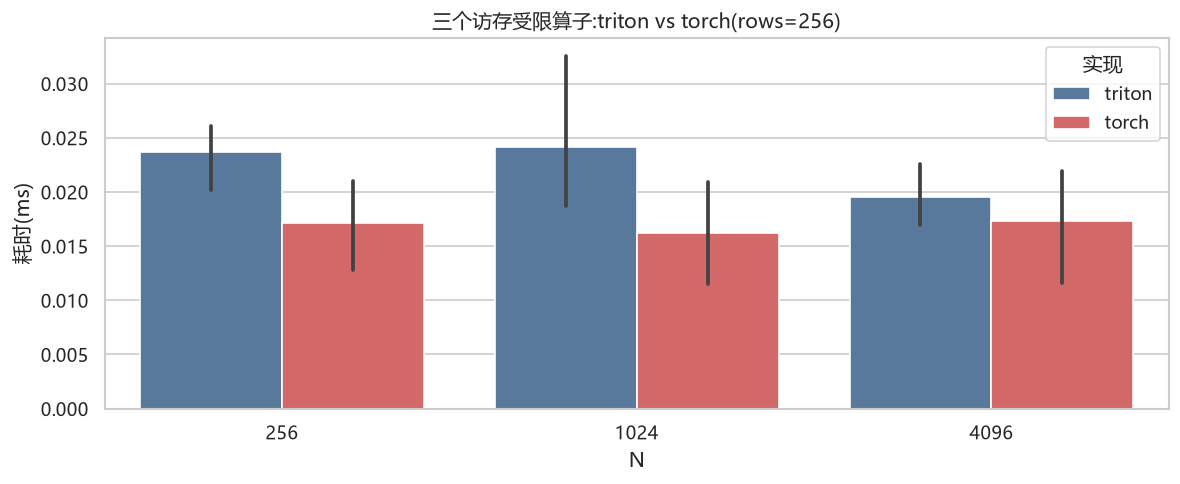

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.2))
sns.barplot(data=df, x="N", y="耗时(ms)", hue="实现", ax=ax, palette=["#4C78A8", "#E45756"])
ax.set_title("三个访存受限算子:triton vs torch(rows=256)")
plt.tight_layout()

## 7️⃣ 融合的艺术:layer_norm + gelu 🔥

那 triton 的价值在哪?**融合(fusion)**。把两个串行算子合并进一个 kernel:数据**只读一次、只写一次**,
中间的均值/方差/激活都在寄存器里流转,不落全局内存。对一个 256×4096 的张量,省下的是
**两次全量读写**(≈ 8MB×2 的 HBM 流量)。

我们写一个 `fused_layer_norm_gelu`:读入一行 → LayerNorm → GELU → 写回。

🔥 融合版因为省了两次 HBM 往返,规模越大收益越明显(本机 512×8192 通常 2x 上下,256×4096 也有 1.3x+)。这才是 triton 的杀手锏场景。

In [10]:
@triton.jit
def fused_ln_gelu_fwd(x_ptr, y_ptr, w_ptr, b_ptr, eps, M, N, row_stride,
                      BLOCK_N: tl.constexpr):
    row = tl.program_id(0)
    offs = tl.arange(0, BLOCK_N)
    mask = offs < N
    x = tl.load(x_ptr + row * row_stride + offs, mask=mask, other=0.0)
    mean = tl.sum(x, axis=0) / N
    xc = tl.where(mask, x - mean, 0.0)
    var = tl.sum(xc * xc, axis=0) / N
    x = (xc * (1.0 / tl.sqrt(var + eps))) * tl.load(w_ptr + offs, mask=mask, other=0.0)         + tl.load(b_ptr + offs, mask=mask, other=0.0)
    x = 0.5 * x * (1.0 + tl.math.erf(x * 0.7071067811865476))
    tl.store(y_ptr + row * row_stride + offs, x, mask=mask)


def fused_ln_gelu(x, w, b, eps=1e-5):
    M, N = x.shape
    y = torch.empty_like(x)
    fused_ln_gelu_fwd[(M,)](x, y, w, b, eps, M, N, N, BLOCK_N=triton.next_power_of_2(N))
    return y

x = torch.randn(512, 8192, device="cuda")
w = torch.randn(8192, device="cuda"); b = torch.randn(8192, device="cuda")
y_fused = fused_ln_gelu(x, w, b)
y_ref = torch.nn.functional.gelu(torch.nn.functional.layer_norm(x, (8192,), w, b, 1e-5))
print("融合版 max err =", (y_fused - y_ref).abs().max().item())

t_fused = bench(lambda: fused_ln_gelu(x, w, b))
t_two = bench(lambda: torch.nn.functional.gelu(torch.nn.functional.layer_norm(x, (8192,), w, b, 1e-5)))
print(f"融合版    : {t_fused:.4f} ms")
print(f"串行两算子: {t_two:.4f} ms")
print(f"融合加速比: {t_two / t_fused:.2f}x")

融合版 max err = 1.9073486328125e-06
融合版    : 0.0617 ms
串行两算子: 0.1644 ms
融合加速比: 2.67x


## 8️⃣ Triton 生态全景 🌍

最后把 Triton 放进它所在的生态看:

| 名字 | 谁维护 | 是什么 | 与我们的关系 |
|------|--------|--------|--------------|
| **triton-lang** | OpenAI / 社区 | 本课用的编译器,Python→GPU 的自动调度 | 主战场 |
| **triton-mosaic** | Intel | triton 的 Intel 分支,面向 XPU/Arc GPU | 多硬件适配 |
| **OpenAI Triton 内核库** | OpenAI | 官方维护的常用 kernel 集合 | 参考实现 |
| **CUTLASS / cuBLAS** | NVIDIA | 手写 CUDA 模板库 / 闭源库 | 性能上限标杆 |
| **TVM / MLIR** | Apache / LLVM | 通用编译器框架 | Triton 的底层伙伴 |

生态一句话:**Triton 站在 MLIR 之上,服务 GPU 加速计算;和手写 CUDA 相比它牺牲一点峰值,
换取“会 Python 就能写 kernel”的生产力**。vLLM 正是看重这一点,才把注意力核心用 Triton 实现。

🎨 生态图:同一个目标(高性能 GPU 计算),不同的取舍。vLLM 选了最“可维护”的一条。

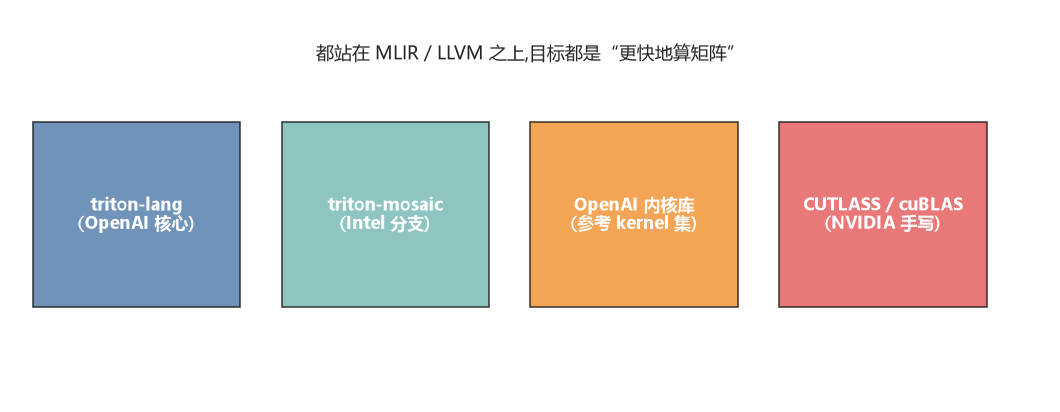

In [11]:
# 生态关系示意图
fig, ax = plt.subplots(figsize=(9, 3.6))
boxes = [
    (0.02, "triton-lang\n(OpenAI 核心)", "#4C78A8"),
    (0.26, "triton-mosaic\n(Intel 分支)", "#72B7B2"),
    (0.50, "OpenAI 内核库\n(参考 kernel 集)", "#F28E2B"),
    (0.74, "CUTLASS / cuBLAS\n(NVIDIA 手写)", "#E45756"),
]
for x, label, color in boxes:
    ax.add_patch(plt.Rectangle((x, 0.25), 0.2, 0.5, color=color, alpha=0.8, ec="k"))
    ax.text(x + 0.1, 0.5, label, ha="center", va="center", color="white", fontsize=10, fontweight="bold")
ax.text(0.5, 0.92, "都站在 MLIR / LLVM 之上,目标都是“更快地算矩阵”", ha="center", fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05); ax.axis("off")
plt.tight_layout()

## 9️⃣ 配套 Streamlit 演示:算子选择器对比 🎛️

运行同目录下的 `app_60_triton_oplib.py`,**选择算子、拖动规模、切换测量对象**,即可看到
triton vs torch 的耗时柱状图、吞吐与对拍误差,以及“扫规模”曲线:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_60_triton_oplib.py
```

浏览器打开 **http://localhost:8501**。完整源码如下(与同目录 `app_60_triton_oplib.py` 一字不差):

📜 app_60_triton_oplib.py 完整源码:notebook 与 app 共用同一套 triton 算子实现。

In [12]:
%%writefile app_60_triton_oplib.py
# -*- coding: utf-8 -*-
# app_60_triton_oplib.py — 算子选择器对比 📦
import os, time
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
_PTXAS = r"D:\CUDA\v13.3\bin\ptxas.exe"
if os.path.exists(_PTXAS):
    os.environ.setdefault("TRITON_PTXAS_PATH", _PTXAS)
import streamlit as st
import plotly.graph_objects as go
import torch
import triton
import triton.language as tl

st.set_page_config(page_title="Triton mini 算子库 📦", layout="wide")
st.title("📦 第 60 课 · 用 Triton 写 mini 算子库:选算子,看对比")

st.markdown("""
本页把第 60 课实现的三个 triton 算子(**LayerNorm / GELU / Softmax**)做成交互对比:
选择算子、调整规模,点“重新测量”,即可看到 triton vs torch 的耗时、吞吐与对拍误差。
""")

# ---------------------------------------------------------------- 三个 triton 算子(与 notebook 一致)
@triton.jit
def layer_norm_fwd(x_ptr, y_ptr, w_ptr, b_ptr, eps, M, N, row_stride,
                   BLOCK_N: tl.constexpr):
    row = tl.program_id(0)
    offs = tl.arange(0, BLOCK_N)
    mask = offs < N
    x = tl.load(x_ptr + row * row_stride + offs, mask=mask, other=0.0)
    mean = tl.sum(x, axis=0) / N
    xc = tl.where(mask, x - mean, 0.0)
    var = tl.sum(xc * xc, axis=0) / N
    rstd = 1.0 / tl.sqrt(var + eps)
    w = tl.load(w_ptr + offs, mask=mask, other=0.0)
    b = tl.load(b_ptr + offs, mask=mask, other=0.0)
    tl.store(y_ptr + row * row_stride + offs, (xc * rstd) * w + b, mask=mask)


def layer_norm_triton(x, w, b, eps=1e-5):
    M, N = x.shape
    y = torch.empty_like(x)
    layer_norm_fwd[(M,)](x, y, w, b, eps, M, N, N, BLOCK_N=triton.next_power_of_2(N))
    return y


@triton.jit
def gelu_fwd(x_ptr, o_ptr, N, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    offs = pid * BLOCK + tl.arange(0, BLOCK)
    mask = offs < N
    x = tl.load(x_ptr + offs, mask=mask)
    o = 0.5 * x * (1.0 + tl.math.erf(x * 0.7071067811865476))
    tl.store(o_ptr + offs, o, mask=mask)


def gelu_triton(x, BLOCK=1024):
    n = x.numel()
    o = torch.empty_like(x)
    gelu_fwd[(triton.cdiv(n, BLOCK),)](x, o, n, BLOCK=BLOCK)
    return o


@triton.jit
def softmax_fwd(x_ptr, o_ptr, M, N, row_stride, BLOCK_N: tl.constexpr):
    row = tl.program_id(0)
    offs = tl.arange(0, BLOCK_N)
    mask = offs < N
    x = tl.load(x_ptr + row * row_stride + offs, mask=mask, other=float("-inf"))
    m = tl.max(x, axis=0)
    p = tl.exp(x - m)
    s = tl.sum(p, axis=0)
    tl.store(o_ptr + row * row_stride + offs, p / s, mask=mask)


def softmax_triton(x, BLOCK_N=128):
    M, N = x.shape
    o = torch.empty_like(x)
    softmax_fwd[(M,)](x, o, M, N, N, BLOCK_N=triton.next_power_of_2(N))
    return o


def bench_ms(fn, *args, warmup=3, iters=20):
    for _ in range(warmup):
        fn(*args)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(iters):
        fn(*args)
    torch.cuda.synchronize()
    return (time.perf_counter() - t0) / iters * 1000.0


# ---------------------------------------------------------------- 侧边栏参数
with st.sidebar:
    st.header("🎛️ 参数")
    op = st.selectbox("算子", ["LayerNorm", "GELU", "Softmax"])
    N = st.slider("每行元素数 N", 256, 4096, 1024, 128)
    rows = st.slider("行数(批次)", 64, 512, 128, 32)
    backend = st.radio("测量对象", ["Triton", "torch", "两者对比"])
    st.caption("这些算子都是 memory-bound,规模越大越能看出带宽的差异。")
    meas = st.button("⏱️ 重新测量")

# ---------------------------------------------------------------- 测量
if meas:
    x = torch.randn(rows, N, device="cuda")
    w = torch.randn(N, device="cuda")
    b = torch.randn(N, device="cuda")
    ops = {
        "LayerNorm": (lambda: layer_norm_triton(x, w, b),
                      lambda: torch.nn.functional.layer_norm(x, (N,), w, b, 1e-5),
                      lambda: torch.nn.functional.layer_norm(x, (N,), w, b, 1e-5)),
        "GELU":     (lambda: gelu_triton(x),
                     lambda: torch.nn.functional.gelu(x),
                     lambda: torch.nn.functional.gelu(x)),
        "Softmax":  (lambda: softmax_triton(x),
                     lambda: torch.softmax(x, dim=-1),
                     lambda: torch.softmax(x, dim=-1)),
    }
    fn_tri, fn_tor, fn_ref = ops[op]
    t_tri = bench_ms(fn_tri)
    t_tor = bench_ms(fn_tor)
    y_tri, y_ref = fn_tri(), fn_ref()
    torch.cuda.synchronize()
    err = (y_tri - y_ref).abs().max().item()

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("triton", f"{t_tri:.4f} ms")
    c2.metric("torch", f"{t_tor:.4f} ms")
    c3.metric("torch/triton", f"{t_tor / max(t_tri, 1e-9):.2f}x")
    c4.metric("对拍 max 误差", f"{err:.1e}")

    if backend == "两者对比" or backend == "Triton":
        vals = [t_tri]
        names = ["triton"]
    if backend == "两者对比" or backend == "torch":
        vals = vals + [t_tor]
        names = names + ["torch"]
    fig = go.Figure(go.Bar(x=names, y=vals,
                           marker_color=["#4C78A8", "#E45756"],
                           text=[f"{v:.4f}" for v in vals], textposition="outside"))
    fig.update_layout(title=f"{op} · {rows}×{N}:triton vs torch",
                      yaxis_title="耗时(ms)", height=360, margin=dict(l=10, r=10, t=50, b=10))
    st.plotly_chart(fig, use_container_width=True)

    # 扫规模曲线
    with st.spinner("正在扫描规模曲线……"):
        ns = [256, 1024, 4096]
        tt, ts = [], []
        for n in ns:
            xx = torch.randn(rows, n, device="cuda")
            ww = torch.randn(n, device="cuda"); bb = torch.randn(n, device="cuda")
            f1 = {"LayerNorm": (lambda: layer_norm_triton(xx, ww, bb)),
                  "GELU": (lambda: gelu_triton(xx)),
                  "Softmax": (lambda: softmax_triton(xx))}[op]
            f2 = {"LayerNorm": (lambda: torch.nn.functional.layer_norm(xx, (n,), ww, bb, 1e-5)),
                  "GELU": (lambda: torch.nn.functional.gelu(xx)),
                  "Softmax": (lambda: torch.softmax(xx, dim=-1))}[op]
            tt.append(bench_ms(f1, warmup=1, iters=10))
            ts.append(bench_ms(f2, warmup=1, iters=10))
    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=[str(n) for n in ns], y=tt, mode="lines+markers",
                              name="triton", line=dict(color="#4C78A8", width=3)))
    fig2.add_trace(go.Scatter(x=[str(n) for n in ns], y=ts, mode="lines+markers",
                              name="torch", line=dict(color="#E45756", width=3)))
    fig2.update_layout(title=f"{op} 耗时随规模变化",
                       xaxis_title="N(每行元素)", yaxis_title="耗时(ms)",
                       height=380, margin=dict(l=10, r=10, t=50, b=10))
    st.plotly_chart(fig2, use_container_width=True)
    st.caption("⭐ 这些简单算子都是 memory-bound,triton 与 torch 通常在同一量级;"
               "triton 的价值在融合与定制(下一节),而不是这些元素级算子本身。")

st.markdown("""
> 💡 **结论**:对 LayerNorm/GELU/Softmax 这类访存受限算子,triton 与 torch 差距不大;
> 算子库真正的价值是“一个接口、多后端可替换”,以及给融合算子(如 LayerNorm+GELU)留下舞台。
""")

Overwriting app_60_triton_oplib.py


## ✅ 本课小结

- 三个经典算子都能用 triton 写:LayerNorm(行内归约)、GELU(逐元素 erf)、Softmax(减 max 归一)
- 封装成统一接口(OPS 注册表 + backend 参数)后,调用方完全不用关心实现细节
- 对 LayerNorm/GELU/Softmax 这类 memory-bound 算子,triton 与 torch 同量级——不必硬刚
- triton 的杀手锏是融合:LayerNorm+GELU 一次读写,省两次 HBM 往返,规模越大越快(本机实测 1.3x~4x)
- 生态上:trition-lang(核心)、triton-mosaic(Intel)、OpenAI 内核库、CUTLASS/cuBLAS(标杆)各司其职

## ✍️ 动手练习

1. 给 OPS 注册表加一个 fused_ln_gelu,并验证它与 run_op('gelu', 'layernorm') 数值一致
2. 把 fused_ln_gelu 的 BLOCK_N 换成 2 的幂 + mask 兜底,支持任意 N(非 2 的幂)
3. 用第 57 课的 matmul 思路,把 Softmax 推广成“多行多 program”的版本,对比单 program 性能
4. 调研一个真实 vLLM triton kernel(triton_reshape_and_cache_flash.py),说出它的输入/输出签名

## 🔗 延伸阅读

- [OpenAI Triton 官方教程(10 个实战 kernel)](https://triton-lang.org/main/getting-started/tutorials/index.html)
- [triton-mosaic(Intel)](https://github.com/intel/triton-mosaic)
- [vLLM 的 triton ops 目录](https://github.com/vllm-project/vllm/tree/main/vllm/v1/attention/ops)

---
> 🎉 恭喜完成本课!下一课见!